In [40]:
import sympy as sp
import numpy as np
import scienceplots 
import matplotlib.pyplot as plt

plt.style.use(["science","no-latex"])

In [41]:
# Define symbols
t = sp.symbols('t', real=True)
zeta, wn,z = sp.symbols('zeta wn z', positive=True)
y = sp.Function('y')

In [42]:
# Define the ODE
ode = sp.Eq(
    y(t).diff(t, 2)
    + 2*zeta*wn*y(t).diff(t,1)
    + wn**2*y(t),
    wn**2
)

ode

Eq(wn**2*y(t) + 2*wn*zeta*Derivative(y(t), t) + Derivative(y(t), (t, 2)), wn**2)

In [43]:
def calc_ode(ode):
    solution = sp.dsolve(
        ode,
        ics={
            y(0): 0,
            y(t).diff(t).subs(t, 0): 0
        }
    )
    return solution

In [44]:
calc_ode(ode)

Eq(y(t), (-zeta/(2*sqrt(zeta - 1)*sqrt(zeta + 1)) - 1/2)*exp(t*wn*(-zeta + sqrt(zeta - 1)*sqrt(zeta + 1))) + (zeta/(2*sqrt(zeta - 1)*sqrt(zeta + 1)) - 1/2)*exp(-t*wn*(zeta + sqrt(zeta - 1)*sqrt(zeta + 1))) + 1)

In [45]:
def get_response(zeta_value,ode):
    t_values=np.linspace(0,10,1000)
    solution_expr=calc_ode(ode.subs(wn,1).subs(zeta,zeta_value)).rhs
    func=sp.lambdify(t,solution_expr,modules=["numpy"])
    response=func(t_values)
    return response,t_values

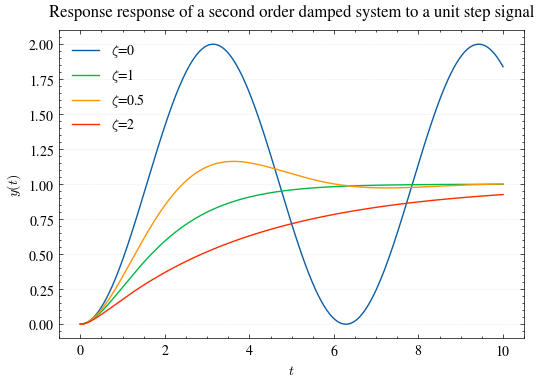

In [46]:
#plotting the function 
zeta_values=[0,1,0.5,2]
fig=plt.figure(figsize=(6,4))
for zeta_value in zeta_values:
    response,t_values=get_response(zeta_value,ode)
    plt.plot(t_values,response,label=f"$\zeta$={zeta_value}")
plt.legend()
plt.grid(True,alpha=0.2,axis='y',linestyle="--")
plt.title("Response response of a second order damped system to a unit step signal",fontsize=12,pad=10)
plt.ylabel("$y(t)$")
plt.xlabel("$t$")
plt.savefig("plot")
plt.show()


response to impulse 

In [47]:
ode = sp.Eq(
    y(t).diff(t, 2)
    + 2*zeta*wn*y(t).diff(t,1)
    + wn**2*y(t),
    0
)
ode

Eq(wn**2*y(t) + 2*wn*zeta*Derivative(y(t), t) + Derivative(y(t), (t, 2)), 0)

In [48]:
def calc_ode(ode):
    solution = sp.dsolve(
        ode,
        ics={
            y(0): 0,
            y(t).diff(t).subs(t, 0): 1
        }
    )
    return solution

In [49]:
calc_ode(ode)

Eq(y(t), exp(t*wn*(-zeta + sqrt(zeta - 1)*sqrt(zeta + 1)))/(2*wn*sqrt(zeta - 1)*sqrt(zeta + 1)) - exp(-t*wn*(zeta + sqrt(zeta - 1)*sqrt(zeta + 1)))/(2*wn*sqrt(zeta - 1)*sqrt(zeta + 1)))

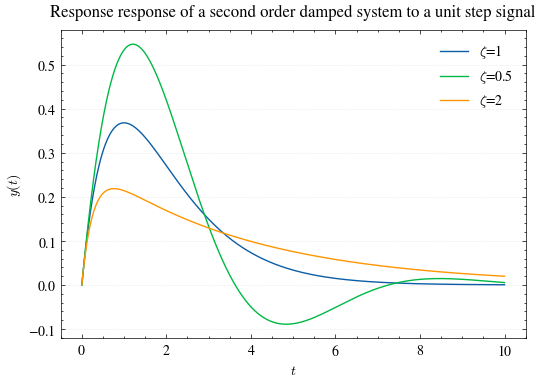

In [51]:
#plotting the function 
zeta_values=[1,0.5,2]
fig=plt.figure(figsize=(6,4))
for zeta_value in zeta_values:
    response,t_values=get_response(zeta_value,ode)
    plt.plot(t_values,response,label=f"$\zeta$={zeta_value}")
plt.legend()
plt.grid(True,alpha=0.2,axis='y',linestyle="--")
plt.title("Response response of a second order damped system to a unit step signal",fontsize=12,pad=10)
plt.ylabel("$y(t)$")
plt.xlabel("$t$")
plt.savefig("plot")
plt.show()
